In [2]:
%pip install numpy pandas scikit-learn imbalanced-learn xgboost lightgbm optuna torch matplotlib seaborn mne 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import itertools
# import matplotlib.pyplot as plt
import mne

In [4]:

# Your bipolar_pairs list
bipolar_pairs = [
    ('EEG Fp1-REF', 'EEG F7-REF'),
    ('EEG F7-REF',  'EEG T3-REF'),
    ('EEG T3-REF',  'EEG T5-REF'),
    ('EEG T5-REF',  'EEG O1-REF'),
    ('EEG Fp1-REF', 'EEG F3-REF'),
    ('EEG F3-REF',  'EEG C3-REF'),
    ('EEG C3-REF',  'EEG P3-REF'),
    ('EEG P3-REF',  'EEG O1-REF'),
    ('EEG Fz-REF',  'EEG Cz-REF'),
    ('EEG Cz-REF',  'EEG Pz-REF'),
    ('EEG Fp2-REF', 'EEG F4-REF'),
    ('EEG F4-REF',  'EEG C4-REF'),
    ('EEG C4-REF',  'EEG P4-REF'),
    ('EEG P4-REF',  'EEG O2-REF'),
    ('EEG Fp2-REF', 'EEG F8-REF'),
    ('EEG F8-REF',  'EEG T4-REF'),
    ('EEG T4-REF',  'EEG T6-REF'),
    ('EEG T6-REF',  'EEG O2-REF'),
]

desired_order = [
    'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2',
    'Fp1-F7', 'F7-T3', 'T3-T5', 'T5-O1',
    'Fz-Cz', 'Cz-Pz',
]

def pair_name(pair):
    # Extract labels removing 'EEG ' and '-REF'
    left = pair[0].replace('EEG ', '').replace('-REF', '')
    right = pair[1].replace('EEG ', '').replace('-REF', '')
    return f"{left}-{right}"

# Create a dict from name to pair for quick lookup
name_to_pair = {pair_name(p): p for p in bipolar_pairs}

# Reorder bipolar_pairs according to desired_order
reordered_pairs = [name_to_pair[name] for name in desired_order]

# Let's print to verify
for name, pair in zip(desired_order, reordered_pairs):
    print(f"{name}: {pair}")

bipolar_pairs = [
    ('EEG Fp1-REF', 'EEG F7-REF'),
    ('EEG F7-REF',  'EEG T3-REF'),
    ('EEG T3-REF',  'EEG T5-REF'),
    ('EEG T5-REF',  'EEG O1-REF'),
    ('EEG Fp1-REF', 'EEG F3-REF'),
    ('EEG F3-REF',  'EEG C3-REF'),
    ('EEG C3-REF',  'EEG P3-REF'),
    ('EEG P3-REF',  'EEG O1-REF'),
    ('EEG Fz-REF',  'EEG Cz-REF'),
    ('EEG Cz-REF',  'EEG Pz-REF'),
    ('EEG Fp2-REF', 'EEG F4-REF'),
    ('EEG F4-REF',  'EEG C4-REF'),
    ('EEG C4-REF',  'EEG P4-REF'),
    ('EEG P4-REF',  'EEG O2-REF'),
    ('EEG Fp2-REF', 'EEG F8-REF'),
    ('EEG F8-REF',  'EEG T4-REF'),
    ('EEG T4-REF',  'EEG T6-REF'),
    ('EEG T6-REF',  'EEG O2-REF'),
]

def normalize_channel(ch):
    return ch.strip().upper()

bipolar_pairs = [(normalize_channel(a), normalize_channel(b)) for a, b in bipolar_pairs]

def make_ch_names(pairs):
    def pretty(ch):
        return ch.replace('EEG ', '').replace('-REF', '').capitalize()
    return [f"{pretty(a)}-{pretty(b)}" for a, b in pairs]

anode = [a for a, _ in bipolar_pairs]
cathode = [b for _, b in bipolar_pairs]
ch_names = make_ch_names(reordered_pairs)



def getArray(filename: str):
    raw = mne.io.read_raw_edf(filename, preload=True)
    raw.rename_channels(lambda ch: ch.upper())
    drop_candidates = ['ECG EKG', 'RESP EFFORT','ECG EKG-REF','RESP EFFORT-REF']
    available = set(raw.ch_names)
    to_drop = [ch for ch in drop_candidates if ch in available]
    if to_drop:
        raw.drop_channels(to_drop)
    raw = mne.set_bipolar_reference(raw, anode=anode, cathode=cathode, ch_name=ch_names, copy=True)
    array = raw.get_data()
    # raw.plot()
    return array

Fp2-F4: ('EEG Fp2-REF', 'EEG F4-REF')
F4-C4: ('EEG F4-REF', 'EEG C4-REF')
C4-P4: ('EEG C4-REF', 'EEG P4-REF')
P4-O2: ('EEG P4-REF', 'EEG O2-REF')
Fp1-F3: ('EEG Fp1-REF', 'EEG F3-REF')
F3-C3: ('EEG F3-REF', 'EEG C3-REF')
C3-P3: ('EEG C3-REF', 'EEG P3-REF')
P3-O1: ('EEG P3-REF', 'EEG O1-REF')
Fp2-F8: ('EEG Fp2-REF', 'EEG F8-REF')
F8-T4: ('EEG F8-REF', 'EEG T4-REF')
T4-T6: ('EEG T4-REF', 'EEG T6-REF')
T6-O2: ('EEG T6-REF', 'EEG O2-REF')
Fp1-F7: ('EEG Fp1-REF', 'EEG F7-REF')
F7-T3: ('EEG F7-REF', 'EEG T3-REF')
T3-T5: ('EEG T3-REF', 'EEG T5-REF')
T5-O1: ('EEG T5-REF', 'EEG O1-REF')
Fz-Cz: ('EEG Fz-REF', 'EEG Cz-REF')
Cz-Pz: ('EEG Cz-REF', 'EEG Pz-REF')


In [5]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
annotations = pd.read_excel('C:/bt23ece064/dataset/annot.xlsx')

In [7]:

import os

eeg_set = []
for i in range(1, 80):
    filepath = f'C:/bt23ece064/dataset/eeg{i}.edf'
    if os.path.exists(filepath):
        try:
            eeg = getArray(filepath)
            eeg_set.append(eeg)
        except ValueError as e:
            print(f"Error in file: {filepath}")
            print(e)
     

Extracting EDF parameters from C:\bt23ece064\dataset\eeg1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1790207  =      0.000 ...  6992.996 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=1790208
    Range : 0 ... 1790207 =      0.000 ...  6992.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg2.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 962815  =      0.000 ...  3760.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_19328\1656997136.py:85: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19328\1656997136.py:85: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=962816
    Range : 0 ... 962815 =      0.000 ...  3760.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg3.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1129471  =      0.000 ...  4411.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_19328\1656997136.py:85: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19328\1656997136.py:85: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=1129472
    Range : 0 ... 1129471 =      0.000 ...  4411.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg4.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 876799  =      0.000 ...  3424.996 secs...


...

EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=1073408
    Range : 0 ... 1073407 =      0.000 ...  4192.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg78.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1272575  =      0.000 ...  4970.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_19328\1656997136.py:85: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19328\1656997136.py:85: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=1272576
    Range : 0 ... 1272575 =      0.000 ...  4970.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg79.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 844031  =      0.000 ...  3296.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_19328\1656997136.py:85: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19328\1656997136.py:85: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=844032
    Range : 0 ... 844031 =      0.000 ...  3296.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz


In [8]:
%pip install PyWavelets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
annotations

,FILE ID,Start,Stop,Fp2-F4,F4-C4,C4-P4,P4-O2,Fp1-F3,F3-C3,C3-P3,...,Fp2-F8,F8-T4,T4-T6,T6-O2,Fp1-F7,F7-T3,T3-T5,T5-O1,Fz-Cz,Cz-Pz
0,NaN,NaN,NaN,1,2,3,4,5,6,7,...,9,10,11,12,13,14,15,16,17,18
1,1.0,104.0,122.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
2,1.0,349.0,428.0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,1.0,760.0,779.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
4,1.0,956.0,965.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,79.0,152.0,190.0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
361,79.0,367.0,384.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
362,79.0,576.0,621.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
363,79.0,2148.0,2163.0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


array([ 1,  4,  5,  7,  9, 11, 13, 14, 15, 16, 17, 19, 20, 21, 22, 25, 31,
       34, 36, 38, 39, 40, 41, 44, 47, 50, 51, 52, 62, 63, 66, 67, 69, 73,
       75, 76, 77, 78, 79])

In [11]:
annotations = annotations.sort_values(by=['FILE ID','Start'], ascending=[True,True])
annotations = annotations.dropna(axis=0)
     
     

import numpy as np


seizured_segments = [
    [np.zeros_like(channel, dtype=float) for channel in patient_eeg] 
    for patient_eeg in eeg_set
]
non_seizured_segments = [
    [np.zeros_like(channel, dtype=float) for channel in patient_eeg] 
    for patient_eeg in eeg_set
]


unordered_seizured_segments = []
unordered_non_seizured_segments = []

channel_cols = ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'Fp1-F3', 'F3-C3', 'C3-P3',
                'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2', 'Fp1-F7', 'F7-T3', 'T3-T5', 
                'T5-O1', 'Fz-Cz', 'Cz-Pz']

print(f"Starting processing {len(annotations)} annotations...")
print(f"Total patients in eeg_set: {len(eeg_set)}")


for i in range(len(annotations)):
    patient = int(annotations['FILE ID'].iloc[i] - 1)
    start = int(annotations['Start'].iloc[i] * 256) 
    stop = int(annotations['Stop'].iloc[i] * 256)
    
    
    print(f"Processing annotation {i+1}/{len(annotations)} - Patient {patient+1}, Time: {annotations['Start'].iloc[i]:.1f}s-{annotations['Stop'].iloc[i]:.1f}s")
    
    seizure_count = 0
    non_seizure_count = 0
    
    for ch_idx, col in enumerate(channel_cols):
        if ch_idx < len(eeg_set[patient]): 
            if annotations[col].iloc[i] == 1: 
                seizured_segments[patient][ch_idx][start:stop] = eeg_set[patient][ch_idx][start:stop]
                non_seizured_segments[patient][ch_idx][start:stop] = 0
                unordered_seizured_segments.append(eeg_set[patient][ch_idx][start:stop])
                seizure_count += 1
            else:  
                seizured_segments[patient][ch_idx][start:stop] = 0
                non_seizured_segments[patient][ch_idx][start:stop] = eeg_set[patient][ch_idx][start:stop]
                unordered_non_seizured_segments.append(eeg_set[patient][ch_idx][start:stop])
                non_seizure_count += 1
    
    print(f"  Annotation {i+1}: {seizure_count} seizure channels, {non_seizure_count} non-seizure channels")

print("\nProcessing complete!")
print(f"Total annotations processed: {len(annotations)}")

Starting processing 364 annotations...
Total patients in eeg_set: 79
Processing annotation 1/364 - Patient 1, Time: 104.0s-122.0s
  Annotation 1: 2 seizure channels, 15 non-seizure channels
Processing annotation 2/364 - Patient 1, Time: 349.0s-428.0s
  Annotation 2: 2 seizure channels, 15 non-seizure channels
Processing annotation 3/364 - Patient 1, Time: 760.0s-779.0s
  Annotation 3: 2 seizure channels, 15 non-seizure channels
Processing annotation 4/364 - Patient 1, Time: 956.0s-965.0s
  Annotation 4: 2 seizure channels, 15 non-seizure channels
Processing annotation 5/364 - Patient 1, Time: 973.0s-982.0s
  Annotation 5: 2 seizure channels, 15 non-seizure channels
Processing annotation 6/364 - Patient 1, Time: 1179.0s-1195.0s
  Annotation 6: 2 seizure channels, 15 non-seizure channels
Processing annotation 7/364 - Patient 1, Time: 1601.0s-1613.0s
  Annotation 7: 1 seizure channels, 16 non-seizure channels
Processing annotation 8/364 - Patient 1, Time: 1622.0s-1632.0s
  Annotation 8: 2

In [ ]:
%pip install PyWavelets


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


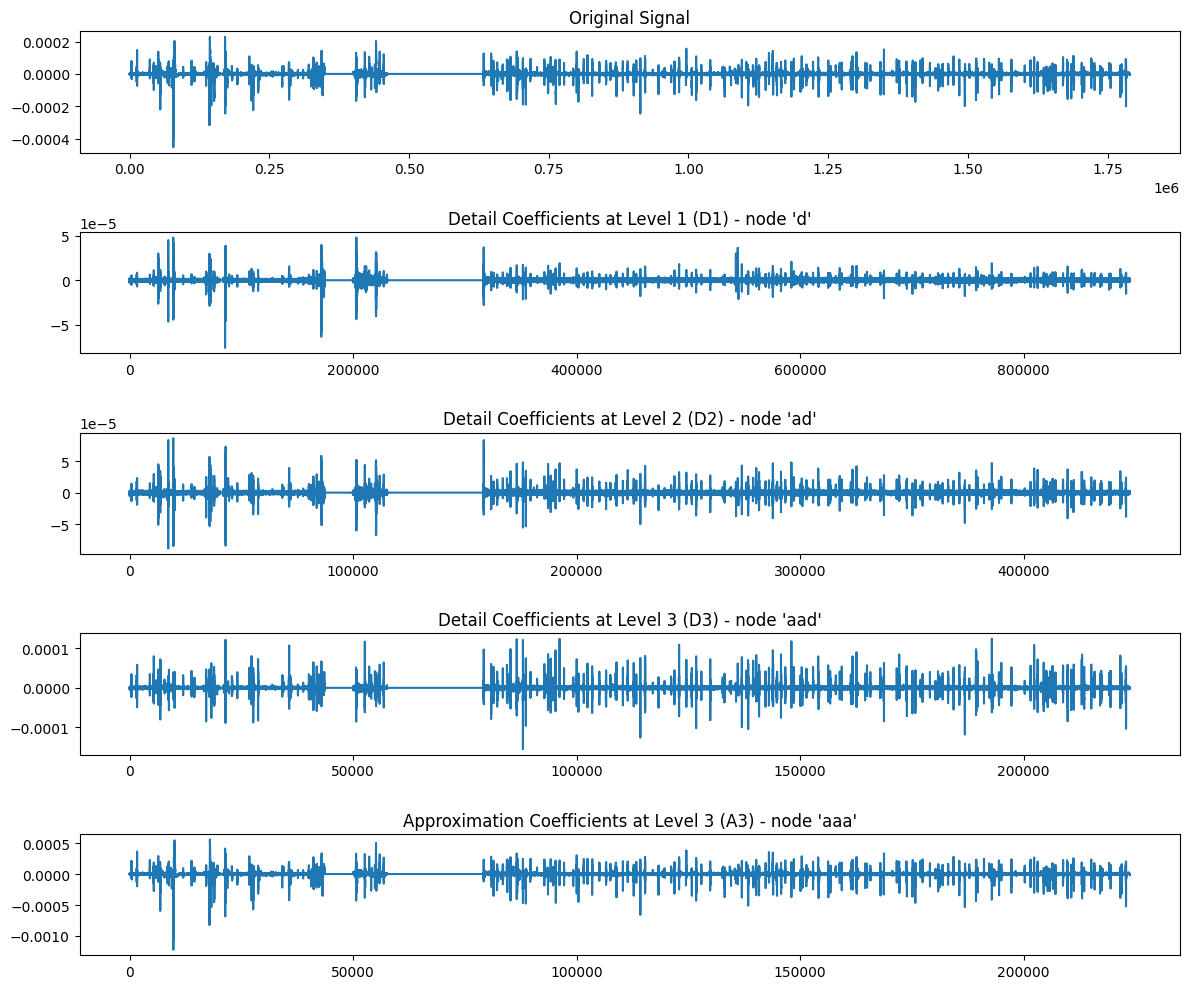

In [12]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
signal = eeg_set[0][0]
wp = pywt.WaveletPacket(data=signal, wavelet='haar', maxlevel=3)

# Extract nodes for D1, D2, D3, and A3
D1 = wp['d']     # detail at level 1
D2 = wp['ad']    # detail at level 2
D3 = wp['aad']   # detail at level 3
A3 = wp['aaa']   # approximation at level 3

# Plot original signal and extracted coefficients
plt.figure(figsize=(12, 10))

plt.subplot(5,1,1)
plt.title("Original Signal")
plt.plot(signal)

plt.subplot(5,1,2)
plt.title("Detail Coefficients at Level 1 (D1) - node 'd'")
plt.plot(D1.data)

plt.subplot(5,1,3)
plt.title("Detail Coefficients at Level 2 (D2) - node 'ad'")
plt.plot(D2.data)

plt.subplot(5,1,4)
plt.title("Detail Coefficients at Level 3 (D3) - node 'aad'")
plt.plot(D3.data)

plt.subplot(5,1,5)
plt.title("Approximation Coefficients at Level 3 (A3) - node 'aaa'")
plt.plot(A3.data)

plt.tight_layout()
plt.show()

array([7.17162525e-06, 7.01903748e-06, 6.86644971e-06, ...,
       6.10351085e-06, 4.88280868e-06, 3.81469428e-06])

In [13]:
import pywt
import pandas as pd
import numpy as np
import random
import pywt  # Make sure you import pywt

# Define wavelet and level
wavelet = 'haar'
level = 4

# EEG indices and train-test split
eeg_idx = [1, 4, 5, 7, 9, 11, 13, 14, 15, 16, 17, 19, 20, 21, 22, 25, 31, 34,
           36, 38, 39, 40, 41, 44, 47, 50, 51, 52, 62, 63, 66, 67, 69, 73, 75,
           76, 77, 78, 79]

random.seed(42)
train_idx = random.sample(eeg_idx, int(len(eeg_idx) * 0.75))
test_idx = [i for i in eeg_idx if i not in train_idx]

def extract_stats(arr):
    return {
        'max': np.max(arr),
        'min': np.min(arr),
        'mean': np.mean(arr),
        'std': np.std(arr)
    }

def extract_features_for_indices(indices):
    feature_list = []
    for i in range(len(annotations)):
        patient_id = int(annotations['FILE ID'].iloc[i])
        
        if patient_id not in indices:
            continue
        
        start = int(annotations['Start'].iloc[i] * 256)
        stop = int(annotations['Stop'].iloc[i] * 256)
        
        print(f"Processing annotation {i+1}/{len(annotations)} - Patient {patient_id}, Time: {annotations['Start'].iloc[i]:.1f}s-{annotations['Stop'].iloc[i]:.1f}s")
        
        for ch_idx, col in enumerate(channel_cols):
            if ch_idx >= len(eeg_set[patient_id - 1]):
                continue
            
            segment = eeg_set[patient_id - 1][ch_idx][start:stop]
            label = 1 if annotations[col].iloc[i] == 1 else 0
            
            if len(segment) == 0:
                continue
            
            # Apply DWT
            coeffs = pywt.wavedec(segment, wavelet=wavelet, level=level)
            # coeffs = [A4, D4, D3, D2, D1]
            A4, D4, D3, D2, D1 = coeffs

            features = {'label': label}
            
            # Extract stats from each coefficient set
            for name, coeff in zip(['A4', 'D4', 'D3', 'D2', 'D1'], [A4, D4, D3, D2, D1]):
                stats = extract_stats(coeff)
                for stat_name, value in stats.items():
                    features[f'{name}_{stat_name}'] = value

            feature_list.append(features)
    
    return pd.DataFrame(feature_list)

# Extract features for training and testing
train_df = extract_features_for_indices(train_idx)
test_df = extract_features_for_indices(test_idx)

# features = ['slope_alpha', 'intercept_alpha', 'midband_alpha','slope_beta', 'intercept_beta', 'midband_beta','slope_gamma', 'intercept_gamma', 'midband_gamma','slope_delta', 'intercept_delta', 'midband_delta','label']
# train_frames = []
# test_frames = []
# for i in train_idx:
#     print(f'[TRAIN] Processing file {i}')
#     sfilename = f'C:/bt23ece064/features/eeg{i}_seizure_features.csv'
#     nsfilename = f'C:/bt23ece064/features/eeg{i}_non_seizure_features.csv'

#     sdf = pd.read_csv(sfilename)
#     nsdf = pd.read_csv(nsfilename)
#     sdf['label'] = 1
#     nsdf['label'] = 0

#     train_frames.append(sdf[features])
#     train_frames.append(nsdf[features])

# train_df1 = pd.concat(train_frames, ignore_index=True)

# for i in test_idx:
#     print(f'[TEST] Processing file {i}')
#     sfilename = f'C:/bt23ece064/features/eeg{i}_seizure_features.csv'
#     nsfilename = f'C:/bt23ece064/features/eeg{i}_non_seizure_features.csv'

#     sdf = pd.read_csv(sfilename)
#     nsdf = pd.read_csv(nsfilename)
#     sdf['label'] = 1
#     nsdf['label'] = 0

#     test_frames.append(sdf[features])
#     test_frames.append(nsdf[features])

# test_df1 = pd.concat(test_frames, ignore_index=True)
# print("Training set sample:")
# print(train_df.head())

# print("\nTesting set sample:")
# print(test_df.head())

# train_df = pd.concat([train_df, train_df1], ignore_index=True)

Processing annotation 1/364 - Patient 1, Time: 104.0s-122.0s
Processing annotation 2/364 - Patient 1, Time: 349.0s-428.0s
Processing annotation 3/364 - Patient 1, Time: 760.0s-779.0s
Processing annotation 4/364 - Patient 1, Time: 956.0s-965.0s
Processing annotation 5/364 - Patient 1, Time: 973.0s-982.0s
Processing annotation 6/364 - Patient 1, Time: 1179.0s-1195.0s
Processing annotation 7/364 - Patient 1, Time: 1601.0s-1613.0s
Processing annotation 8/364 - Patient 1, Time: 1622.0s-1632.0s
Processing annotation 9/364 - Patient 1, Time: 2850.0s-2860.0s
Processing annotation 10/364 - Patient 1, Time: 3023.0s-3033.0s
Processing annotation 11/364 - Patient 1, Time: 3074.0s-3095.0s
Processing annotation 12/364 - Patient 1, Time: 3258.0s-3272.0s
Processing annotation 13/364 - Patient 1, Time: 3854.0s-3867.0s
Processing annotation 14/364 - Patient 1, Time: 4025.0s-4039.0s
Processing annotation 15/364 - Patient 1, Time: 4066.0s-4086.0s
Processing annotation 16/364 - Patient 1, Time: 4430.0s-449

In [14]:
train_df

,label,A4_max,A4_min,A4_mean,A4_std,D4_max,D4_min,D4_mean,D4_std,D3_max,...,D3_mean,D3_std,D2_max,D2_min,D2_mean,D2_std,D1_max,D1_min,D1_mean,D1_std
0,0,0.000020,-0.000017,1.064141e-06,0.000008,0.000007,-0.000006,9.112881e-08,0.000002,0.000004,...,-5.806895e-09,0.000001,0.000003,-0.000004,1.589456e-08,1.083417e-06,0.000002,-1.618438e-06,-1.311234e-09,5.787351e-07
1,0,0.000015,-0.000014,6.091590e-07,0.000006,0.000010,-0.000008,-3.298121e-08,0.000002,0.000006,...,-2.706762e-08,0.000001,0.000003,-0.000003,-8.145962e-09,6.132411e-07,0.000001,-9.710626e-07,-9.834257e-10,3.103374e-07
2,0,0.000020,-0.000021,1.043345e-06,0.000007,0.000006,-0.000007,-1.364283e-08,0.000002,0.000005,...,1.404894e-09,0.000001,0.000004,-0.000003,-1.655683e-09,7.201988e-07,0.000002,-1.618438e-06,-4.214682e-10,3.488627e-07
3,0,0.000030,-0.000023,-2.247756e-06,0.000009,0.000007,-0.000010,-1.483492e-08,0.000002,0.000004,...,-2.922179e-08,0.000001,0.000005,-0.000004,-2.251729e-09,1.199168e-06,0.000002,-1.942125e-06,1.685873e-09,6.057451e-07
4,0,0.000024,-0.000018,1.926950e-06,0.000008,0.000006,-0.000005,8.265171e-08,0.000002,0.000004,...,-3.821311e-08,0.000001,0.000004,-0.000004,7.947280e-10,1.406193e-06,0.000002,-2.157917e-06,-7.492767e-10,7.648302e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4024,0,0.000210,-0.000145,-2.209901e-06,0.000056,0.000074,-0.000073,3.186687e-07,0.000015,0.000038,...,3.839284e-08,0.000006,0.000019,-0.000020,-2.131608e-08,2.570090e-06,0.000007,-7.808251e-06,3.602292e-09,1.010194e-06
4025,0,0.000293,-0.000242,7.471354e-07,0.000078,0.000053,-0.000105,4.759251e-08,0.000014,0.000028,...,8.759256e-08,0.000006,0.000014,-0.000016,5.027378e-08,2.959999e-06,0.000010,-1.088423e-05,-2.132936e-09,1.622733e-06
4026,0,0.001297,-0.001497,-5.799979e-05,0.000657,0.000063,-0.000104,-6.441747e-08,0.000017,0.000035,...,-2.343859e-07,0.000009,0.000058,-0.000039,1.960677e-08,7.288281e-06,0.000035,-4.270877e-05,-3.628361e-08,5.874736e-06
4027,1,0.000203,-0.000307,-2.256555e-06,0.000098,0.000064,-0.000042,-4.050056e-07,0.000011,0.000033,...,-6.095457e-08,0.000007,0.000030,-0.000047,-5.677585e-08,5.697975e-06,0.000035,-4.401014e-05,-1.502535e-08,4.924884e-06


,label,A4_max,A4_min,A4_mean,A4_std,D4_max,D4_min,D4_mean,D4_std,D3_max,...,midband_alpha,slope_beta,intercept_beta,midband_beta,slope_gamma,intercept_gamma,midband_gamma,slope_delta,intercept_delta,midband_delta


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import numpy as np
from collections import Counter

# Assuming train_df and test_df are already loaded

features = train_df.columns[1:]

# Replace inf with NaN and impute median in train
train_df[features] = train_df[features].replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy='median')
train_df[features] = imputer.fit_transform(train_df[features])

# Replace inf with NaN and impute median in test
test_df[features] = test_df[features].replace([np.inf, -np.inf], np.nan)
test_df[features] = imputer.transform(test_df[features])

# Extract features and labels
X_train = train_df[features].astype('float32').values
X_test = test_df[features].astype('float32').values

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['label'])
y_test = label_encoder.transform(test_df['label'])

# Log transform and scale features
# X_train = np.log1p(X_train)
# X_test = np.log1p(X_test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to balance classes in training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = X_train_scaled, y_train


# Compute class weights (optional after SMOTE, but usually less needed)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_resampled), y=y_train_resampled)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(f"Class weights {class_weights_tensor}")

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_resampled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Now you can create DataLoader, define your model, loss, and optimizer
# Example for DataLoader:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# You’re ready to build and train your model!


Class weights tensor([0.6031, 2.9238])


In [ ]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EEGDataset(X_train_scaled, y_train)
test_dataset = EEGDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [ ]:
class_weights_tensor

tensor([0.6031, 2.9238])

In [ ]:
import torch
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, input_dim):
        super(NeuralNet, self).__init__()
        self.net = nn.Sequential(
      
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.BatchNorm1d(64),
        nn.Dropout(0.2),
        
       
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.BatchNorm1d(32),
        nn.Dropout(0.3),
        
       
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.BatchNorm1d(16),
        nn.Dropout(0.2),
        
     
        nn.Linear(16, 1)
    )
    def forward(self, x):
        return self.net(x)

# Example usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeuralNet(X_train_scaled.shape[1]).to(device)


In [ ]:
pos_weight = torch.tensor([2.9238/0.6031]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-7)

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
import numpy as np

# Assuming these are defined elsewhere in your code
# model, criterion, optimizer, scheduler, train_loader, test_loader, device, threshold

threshold = 0.52  # Your threshold
best_test_loss = float('inf')
patience = 20
epochs_no_improve = 0
history = {
    'loss': [], 'test_loss': [], 'accuracy': [], 'test_accuracy': [], 'test_auc': []
}

for epoch in range(1, 501):
    # === TRAINING PHASE ===
    model.train()
    train_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.view(-1, 1).float().to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

        # Training accuracy calculation
        with torch.no_grad():  # No gradients needed for accuracy calculation
            preds = (torch.sigmoid(outputs) > threshold).float()  # Keep as float for consistency
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    avg_train_loss = train_loss / total
    train_acc = correct / total

    # === EVALUATION PHASE ===
    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch_float = y_batch.view(-1, 1).float().to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch_float)
            test_loss += loss.item() * X_batch.size(0)

            # Get probabilities and store for AUC calculation
            probs = torch.sigmoid(outputs).squeeze()
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

            # Test accuracy calculation
            preds = (probs > threshold).float()
            test_correct += (preds.cpu() == y_batch_float.squeeze().cpu()).sum().item()
            test_total += y_batch.size(0)

    avg_test_loss = test_loss / test_total
    test_acc = test_correct / test_total

    # Calculate AUC with better error handling
    try:
        # Check if we have both classes in the test set
        unique_targets = np.unique(all_targets)
        if len(unique_targets) > 1:
            test_auc = roc_auc_score(all_targets, all_probs)
        else:
            print(f"Warning: Only one class present in test set at epoch {epoch}")
            test_auc = float('nan')
    except ValueError as e:
        print(f"Warning: Could not calculate AUC at epoch {epoch}: {e}")
        test_auc = float('nan')

    # Update learning rate scheduler
    scheduler.step(avg_test_loss)

    # Print progress
    print(f"Epoch {epoch:03d}: "
          f"Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Test Loss={avg_test_loss:.4f}, Test Acc={test_acc:.4f}, Test AUC={test_auc:.4f}")

    # Store history
    history['loss'].append(avg_train_loss)
    history['test_loss'].append(avg_test_loss)
    history['accuracy'].append(train_acc)
    history['test_accuracy'].append(test_acc)
    history['test_auc'].append(test_auc)

    # Early stopping based on test loss
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        torch.save(model.state_dict(), "best_model.pt")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

# Load best model
model.load_state_dict(torch.load("best_model.pt"))
print("Best model loaded.")


Epoch 001: Train Loss=1.0737, Train Acc=0.6701, Test Loss=1.1037, Test Acc=0.7572, Test AUC=0.5147
Epoch 002: Train Loss=1.0872, Train Acc=0.6679, Test Loss=1.1033, Test Acc=0.7628, Test AUC=0.5120
Epoch 003: Train Loss=1.0711, Train Acc=0.6796, Test Loss=1.1063, Test Acc=0.7624, Test AUC=0.5162
Epoch 004: Train Loss=1.0726, Train Acc=0.6721, Test Loss=1.1083, Test Acc=0.7320, Test AUC=0.5148
Epoch 005: Train Loss=1.0827, Train Acc=0.6664, Test Loss=1.1010, Test Acc=0.7708, Test AUC=0.5203
Epoch 006: Train Loss=1.0744, Train Acc=0.6684, Test Loss=1.1119, Test Acc=0.7157, Test AUC=0.5178
Epoch 007: Train Loss=1.0879, Train Acc=0.6652, Test Loss=1.1094, Test Acc=0.7236, Test AUC=0.5128
Epoch 008: Train Loss=1.0749, Train Acc=0.6659, Test Loss=1.1076, Test Acc=0.7316, Test AUC=0.5122
Epoch 009: Train Loss=1.0863, Train Acc=0.6548, Test Loss=1.1087, Test Acc=0.7297, Test AUC=0.5134
Epoch 010: Train Loss=1.0900, Train Acc=0.6704, Test Loss=1.1065, Test Acc=0.7451, Test AUC=0.5202
Epoch 011:

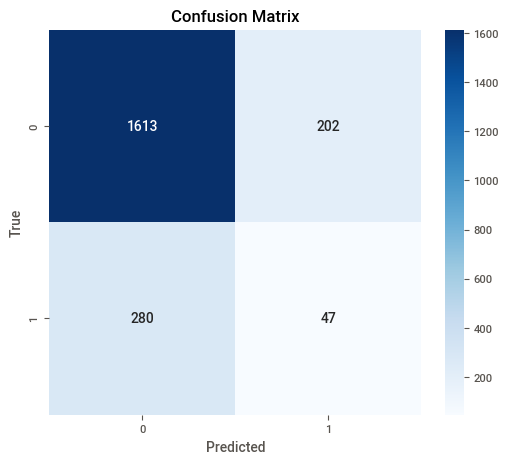

Precision: 0.1888
Recall:    0.1437
F1-score:  0.1632
AUROC: 0.5116
[[1613  202]
 [ 280   47]]


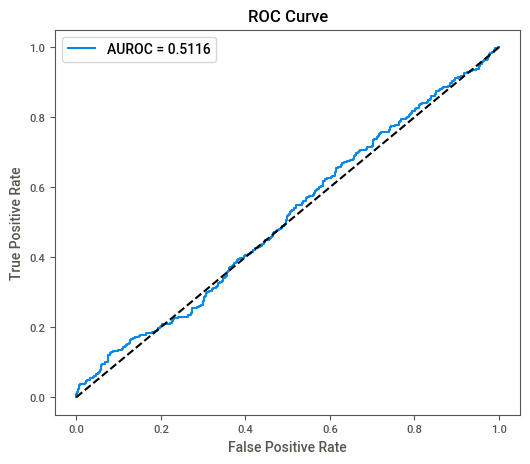

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score, roc_curve

# === Evaluation ===
model.eval()
all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
        preds = (probs > threshold).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

# === Confusion Matrix ===
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# === Precision, Recall, F1 ===
precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='binary')
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# === AUROC and ROC Curve ===
auc_score = roc_auc_score(all_targets, all_probs)
print(f"AUROC: {auc_score:.4f}")
print(cm)
fpr, tpr, _ = roc_curve(all_targets, all_probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUROC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [ ]:
%pip install xgboost

     -------------------------------------- 150.0/150.0 MB 8.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[I 2025-06-25 16:57:11,068] A new study created in memory with name: no-name-e900b460-0951-4886-89b5-21d1d34abfc3


scale_pos_weight: 4.85


[I 2025-06-25 16:57:13,117] Trial 0 finished with value: 0.4831315658671789 and parameters: {'n_estimators': 437, 'max_depth': 12, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182}. Best is trial 0 with value: 0.4831315658671789.
[I 2025-06-25 16:57:13,284] Trial 1 finished with value: 0.5058575749151228 and parameters: {'n_estimators': 240, 'max_depth': 3, 'learning_rate': 0.13983740016490973, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227}. Best is trial 1 with value: 0.5058575749151228.
[I 2025-06-25 16:57:13,964] Trial 2 finished with value: 0.4824121111026866 and parameters: {'n_estimators': 118, 'max_depth': 12, 'learning_rate': 0.11536162338241392, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503}. Best is trial 1 with value: 0.5058575749151228.
[I 2025-06-25 16:57:14,369] Trial 3 finished with value: 0.5026073916816203 and parameters: {'n_estimators': 265, 'max_depth': 6

Best trial: FrozenTrial(number=40, state=1, values=[0.5742099898063201], datetime_start=datetime.datetime(2025, 6, 25, 16, 58, 6, 881465), datetime_complete=datetime.datetime(2025, 6, 25, 16, 58, 7, 438453), params={'n_estimators': 678, 'max_depth': 3, 'learning_rate': 0.0025140500710472777, 'subsample': 0.9492770942635396, 'colsample_bytree': 0.803214529829795}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'max_depth': IntDistribution(high=12, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None)}, trial_id=40, value=None)

Classification Report:
              precision    recall  f1-score   support

           0     0.8805    0.6579    0.7531      1815
           1     0.2099    0.5046   

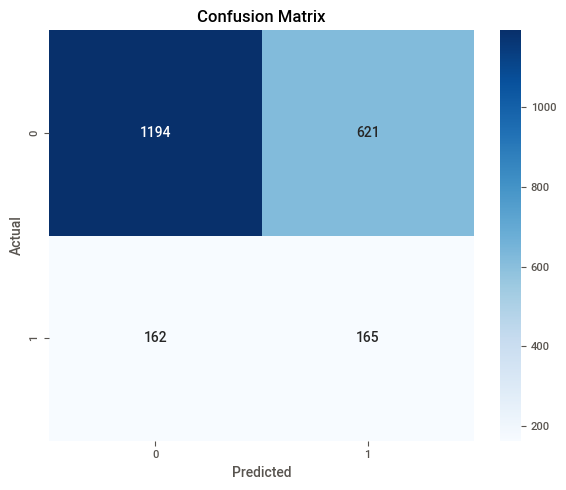

In [ ]:
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")



# === 3. Feature Scaling ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === 4. Handle Class Imbalance ===
# scale_pos_weight = (negative / positive)
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# === 5. Optuna Objective ===
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'use_label_encoder': False,
        'random_state': 42
    }

    model = XGBClassifier(**params)
    model.fit(X_train_scaled, y_train)
    preds = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, preds)
    return auc

# === 6. Run Optimization ===
sampler = optuna.samplers.RandomSampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50)
print("Best trial:", study.best_trial)

# === 7. Train Final Model with Best Params ===
best_params = study.best_params
best_params['scale_pos_weight'] = scale_pos_weight
best_params['objective'] = 'binary:logistic'
best_params['eval_metric'] = 'auc'
best_params['use_label_encoder'] = False
best_params['random_state'] = 42

final_model = XGBClassifier(**best_params)
final_model.fit(X_train_scaled, y_train)

# === 8. Predictions & Metrics ===
y_pred = final_model.predict(X_test_scaled)
y_probs = final_model.predict_proba(X_test_scaled)[:, 1]

conf_mat = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probs)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))
print(f"AUROC: {auc:.4f}")

# === 9. Plot Confusion Matrix ===
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


[I 2025-06-25 16:58:55,960] A new study created in memory with name: no-name-9feabba9-6045-443d-9531-631fc7992d76
[I 2025-06-25 16:58:57,388] Trial 0 finished with value: 0.49485177041473954 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182}. Best is trial 0 with value: 0.49485177041473954.
[I 2025-06-25 16:58:57,527] Trial 1 finished with value: 0.512956082931062 and parameters: {'n_estimators': 162, 'max_depth': 3, 'learning_rate': 0.13983740016490973, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227}. Best is trial 1 with value: 0.512956082931062.
[I 2025-06-25 16:58:58,132] Trial 2 finished with value: 0.5091380864525151 and parameters: {'n_estimators': 108, 'max_depth': 10, 'learning_rate': 0.11536162338241392, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503}. Best is trial 1 with value: 0.512956082931062.
[I 2025-06-25 1

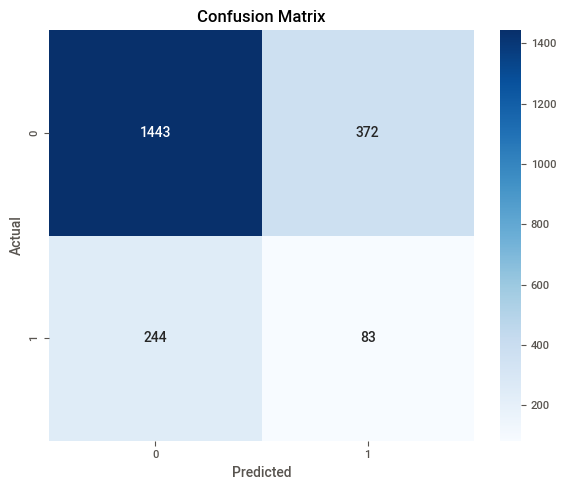

({'0': {'precision': 0.8553645524599881,
   'recall': 0.7950413223140496,
   'f1-score': 0.8241005139920046,
   'support': 1815.0},
  '1': {'precision': 0.1824175824175824,
   'recall': 0.25382262996941896,
   'f1-score': 0.21227621483375958,
   'support': 327.0},
  'accuracy': 0.7124183006535948,
  'macro avg': {'precision': 0.5188910674387852,
   'recall': 0.5244319761417342,
   'f1-score': 0.5181883644128821,
   'support': 2142.0},
  'weighted avg': {'precision': 0.7526317517112174,
   'recall': 0.7124183006535948,
   'f1-score': 0.7306987652409559,
   'support': 2142.0}},
 np.float64(0.576434907877777))

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import optuna
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# 3. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# 5. Compute scale_pos_weight for XGBoost (optional if using SMOTE)
# Use scale_pos_weight = 1 since data is now balanced

# 6. Optuna objective function
def objective(trial):
    try:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'use_label_encoder': False,
            'random_state': 42
        }

        model = XGBClassifier(**params)
        model.fit(X_train_scaled, y_train_res)

        preds = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, preds)
        return auc

    except Exception as e:
        return 0.0

# 7. Run optimization with safe sampler
sampler = optuna.samplers.RandomSampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=30)

# 8. Train final model
best_params = study.best_params
best_params.update({'objective': 'binary:logistic', 'eval_metric': 'auc',
                    'use_label_encoder': False, 'random_state': 42})
final_model = XGBClassifier(**best_params)
final_model.fit(X_train_scaled, y_train_res)

# 9. Evaluate on test set
y_pred = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1]
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
auroc = roc_auc_score(y_test, y_proba)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

report, auroc


In [ ]:
%pip install lightgbm

     ---------------------------------------- 1.5/1.5 MB 2.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# Install required packages if you haven't already:
# pip install optuna xgboost lightgbm imbalanced-learn matplotlib seaborn scikit-learn

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import lightgbm as lgb



# === 2. Apply SMOTE to balance training data ===
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# === 3. Optuna objective for both XGB and LGBM ===
def objective(trial, model_type='xgb'):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42
    }
    if model_type == 'lgb':
        params.update({'objective': 'binary', 'metric': 'auc'})
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train_scaled, y_train_res,
                  eval_set=[(X_test_scaled, y_test)])
    else:
        params.update({'objective': 'binary:logistic', 'eval_metric': 'auc', 'use_label_encoder': False})
        model = XGBClassifier(**params)
        model.fit(X_train_scaled, y_train_res,
                  eval_set=[(X_test_scaled, y_test)])
    proba = model.predict_proba(X_test_scaled)[:, 1]
    return roc_auc_score(y_test, proba)

# === 4. Run Optuna studies ===
sampler = optuna.samplers.RandomSampler(seed=42)

study_xgb = optuna.create_study(direction='maximize', sampler=sampler)
study_xgb.optimize(lambda t: objective(t, 'xgb'), n_trials=30)
print("XGB best AUC:", study_xgb.best_value, "params:", study_xgb.best_params)

study_lgb = optuna.create_study(direction='maximize', sampler=sampler)
study_lgb.optimize(lambda t: objective(t, 'lgb'), n_trials=30)
print("LGBM best AUC:", study_lgb.best_value, "params:", study_lgb.best_params)

# === 5. Train final models ===
def train_and_eval(model_cls, best_params):
    best_params = best_params.copy()
    best_params.update({'random_state': 42})
    model = model_cls(**best_params)

    model.fit(X_train_scaled, y_train_res)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)

    # Plot confusion matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_cls.__name__} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(f"=== {model_cls.__name__} Metrics ===")
    print(f"Precision: {report['1']['precision']:.4f}")
    print(f"Recall:    {report['1']['recall']:.4f}")
    print(f"F1-score:  {report['1']['f1-score']:.4f}")
    print(f"AUROC:     {auc:.4f}\n")

# Prepare parameter dicts
xgb_params = study_xgb.best_params.copy()
xgb_params.update({'objective': 'binary:logistic', 'eval_metric': 'auc', 'use_label_encoder': False})
train_and_eval(XGBClassifier, xgb_params)

lgb_params = study_lgb.best_params.copy()
lgb_params.update({'objective': 'binary', 'metric': 'auc'})
train_and_eval(lgb.LGBMClassifier, lgb_params)


NameError: name 'X_train' is not defined

In [18]:
import numpy as np
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBClassifier
import lightgbm as lgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# === ASSUMING train_df and test_df are already loaded and cleaned ===

# Prepare data
y_train = train_df['label'].values
y_test = test_df['label'].values
X_train = train_df.drop('label', axis=1).values
X_test = test_df.drop('label', axis=1).values

# SMOTE + scaling
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


# Tune base models (XGB and LGB) with Optuna
def objective(trial, model_type='xgb'):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42
    }

    if model_type == 'xgb':
        params.update({'objective': 'binary:logistic', 'eval_metric': 'auc', 'verbosity': 0})
        model = XGBClassifier(**params)
    else:
        params.update({'objective': 'binary', 'metric': 'auc', 'verbosity': -1})
        model = lgb.LGBMClassifier(**params)

    model.fit(X_train_scaled, y_train_res)
    preds = model.predict_proba(X_test_scaled)[:, 1]
    return roc_auc_score(y_test, preds)

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(lambda t: objective(t, 'xgb'), n_trials=20)

lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(lambda t: objective(t, 'lgb'), n_trials=20)

xgb_params = xgb_study.best_params
xgb_params.update({'objective': 'binary:logistic', 'eval_metric': 'auc', 'verbosity': 0})

lgb_params = lgb_study.best_params
lgb_params.update({'objective': 'binary', 'metric': 'auc', 'verbosity': -1})

# K-Fold stacking to create meta features
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

oof_train = np.zeros((X_train_scaled.shape[0], 2))
test_meta = np.zeros((X_test_scaled.shape[0], 2, n_folds))

for i, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train_res)):
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train_res[train_idx], y_train_res[val_idx]

    xgb = XGBClassifier(**xgb_params)
    lgbm = lgb.LGBMClassifier(**lgb_params)

    xgb.fit(X_tr, y_tr)
    lgbm.fit(X_tr, y_tr)

    oof_train[val_idx, 0] = xgb.predict_proba(X_val)[:, 1]
    oof_train[val_idx, 1] = lgbm.predict_proba(X_val)[:, 1]

    test_meta[:, 0, i] = xgb.predict_proba(X_test_scaled)[:, 1]
    test_meta[:, 1, i] = lgbm.predict_proba(X_test_scaled)[:, 1]

X_meta_train = oof_train
X_meta_test = test_meta.mean(axis=2)

# Prepare tensors for PyTorch
X_meta_train_t = torch.tensor(X_meta_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train_res, dtype=torch.float32).unsqueeze(1)
X_meta_test_t = torch.tensor(X_meta_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Define PyTorch meta-model
class MetaNN(nn.Module):
    def __init__(self, input_dim, n_layers, hidden_units, dropout):
        super().__init__()
        layers = []
        current_dim = input_dim
        for i in range(n_layers):
            layers.append(nn.Linear(current_dim, hidden_units[i]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_units[i]
        layers.append(nn.Linear(current_dim, 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Training function
def train_model(model, optimizer, criterion, train_loader, val_loader, epochs, device):
    model.to(device)
    best_val_auc = 0
    best_state = None

    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_preds.append(preds.cpu())
                val_labels.append(yb.cpu())
        val_preds = torch.cat(val_preds).numpy()
        val_labels = torch.cat(val_labels).numpy()
        val_auc = roc_auc_score(val_labels, val_preds)
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = model.state_dict()

    model.load_state_dict(best_state)
    return best_val_auc

# Optuna objective for PyTorch meta-model
def pytorch_objective(trial):
    n_layers = trial.suggest_int("n_layers", 2, 4)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    epochs = trial.suggest_int("epochs", 10, 100)

    hidden_units = [trial.suggest_int(f"units_l{i}", 8, 64) for i in range(n_layers)]

    dataset = TensorDataset(X_meta_train_t, y_train_t)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MetaNN(X_meta_train.shape[1], n_layers, hidden_units, dropout)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    val_auc = train_model(model, optimizer, criterion, train_loader, val_loader, epochs, device)
    return val_auc

study = optuna.create_study(direction='maximize')
study.optimize(pytorch_objective, n_trials=30)

print("Best PyTorch Meta-NN Params:", study.best_params)
print("Best Validation AUC:", study.best_value)

# Train final PyTorch meta-model
best = study.best_params
n_layers = best.pop('n_layers')
epochs = best.pop('epochs')
batch_size = best.pop('batch_size')
dropout = best.pop('dropout')
lr = best.pop('lr')
hidden_units = [best[f'units_l{i}'] for i in range(n_layers)]

final_model = MetaNN(X_meta_train.shape[1], n_layers, hidden_units, dropout)
optimizer = optim.Adam(final_model.parameters(), lr=lr)
criterion = nn.BCELoss()

full_dataset = TensorDataset(X_meta_train_t, y_train_t)
full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
final_model.to(device)

final_model.train()
for _ in range(epochs):
    for xb, yb in full_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = final_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

# Evaluate final model
final_model.eval()
with torch.no_grad():
    preds_test = final_model(X_meta_test_t.to(device)).cpu().numpy().ravel()

preds_class = (preds_test > 0.5).astype(int)

cm = confusion_matrix(y_test, preds_class)
report = classification_report(y_test, preds_class, digits=4)
auc = roc_auc_score(y_test, preds_test)

print("=== Final PyTorch Meta-Model Performance ===")
print(report)
print(f"AUROC: {auc:.4f}")


[I 2025-06-26 15:13:11,624] A new study created in memory with name: no-name-f9420a8a-22f8-4f04-94de-fc2ab200c792
[I 2025-06-26 15:13:12,454] Trial 0 finished with value: 0.4698300772529296 and parameters: {'n_estimators': 137, 'learning_rate': 0.008552210938580173, 'max_depth': 8, 'subsample': 0.9240311209520236, 'colsample_bytree': 0.9722557041000909}. Best is trial 0 with value: 0.4698300772529296.
[I 2025-06-26 15:13:12,637] Trial 1 finished with value: 0.48005998264547056 and parameters: {'n_estimators': 122, 'learning_rate': 0.07263693504285833, 'max_depth': 5, 'subsample': 0.7892461020297675, 'colsample_bytree': 0.8479111349446158}. Best is trial 1 with value: 0.48005998264547056.
[I 2025-06-26 15:13:12,871] Trial 2 finished with value: 0.5774787070033108 and parameters: {'n_estimators': 177, 'learning_rate': 0.0014862736664366105, 'max_depth': 4, 'subsample': 0.7438898104500127, 'colsample_bytree': 0.9317395561526196}. Best is trial 2 with value: 0.5774787070033108.
[I 2025-06-

Best PyTorch Meta-NN Params: {'n_layers': 3, 'dropout': 0.38040924277582777, 'lr': 0.0005046027288679978, 'batch_size': 32, 'epochs': 39, 'units_l0': 16, 'units_l1': 60, 'units_l2': 46}
Best Validation AUC: 0.7346142208774584
=== Final PyTorch Meta-Model Performance ===
              precision    recall  f1-score   support

           0     0.8544    0.8435    0.8489      1815
           1     0.1886    0.2018    0.1950       327

    accuracy                         0.7456      2142
   macro avg     0.5215    0.5227    0.5219      2142
weighted avg     0.7527    0.7456    0.7491      2142

AUROC: 0.5757


In [19]:
print(cm)

[[1531  284]
 [ 261   66]]
